In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.read_csv("data/synthetic_student_week_data.csv")

# Keep boolean versions for readable filtering/plots
df["treatment_b"] = df["treatment"].astype(bool)
df["post_b"] = df["post_period"].astype(bool)

# Use int versions for stable statsmodels naming
df["treatment"] = df["treatment_b"].astype(int)      # 0/1
df["post_period"] = df["post_b"].astype(int)         # 0/1

# Quick sanity checks
assert df["treatment"].isin([0, 1]).all()
assert df["post_period"].isin([0, 1]).all()

print("Rows:", len(df), "Students:", df["student_id"].nunique())
df.head()

Rows: 90761 Students: 8000


,student_id,grade_level,ses_band,baseline_score,baseline_engagement,treatment,week,post_period,weekly_active_days,assignments_completed,engagement_index,assessment_score,treatment_b,post_b
0,1,6,mid,72.786471,3.15067,0,1,0,3,2,2.5,69.946917,False,False
1,1,6,mid,72.786471,3.15067,0,3,0,2,2,2.0,71.182093,False,False
2,1,6,mid,72.786471,3.15067,0,4,0,4,5,4.5,70.695706,False,False
3,1,6,mid,72.786471,3.15067,0,5,0,4,1,2.5,72.494023,False,False
4,1,6,mid,72.786471,3.15067,0,6,0,3,2,2.5,72.593499,False,False


In [2]:
PRIMARY_OUTCOME = "weekly_active_days"
SECONDARY_OUTCOMES = ["assignments_completed", "engagement_index", "assessment_score"]

# Optional: confirm columns exist
needed = [PRIMARY_OUTCOME] + SECONDARY_OUTCOMES + ["grade_level", "ses_band"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

print("Primary outcome:", PRIMARY_OUTCOME)
print("Secondary outcomes:", SECONDARY_OUTCOMES)

Primary outcome: weekly_active_days
Secondary outcomes: ['assignments_completed', 'engagement_index', 'assessment_score']


In [3]:
means = (
    df.groupby(["treatment_b", "post_b"], as_index=False)[PRIMARY_OUTCOME]
      .mean()
      .rename(columns={"treatment_b": "treatment", "post_b": "post_period"})
)

display(means)

# Extract four means
mean_treat_post = means.query("treatment == True and post_period == True")[PRIMARY_OUTCOME].iloc[0]
mean_treat_pre  = means.query("treatment == True and post_period == False")[PRIMARY_OUTCOME].iloc[0]
mean_ctrl_post  = means.query("treatment == False and post_period == True")[PRIMARY_OUTCOME].iloc[0]
mean_ctrl_pre   = means.query("treatment == False and post_period == False")[PRIMARY_OUTCOME].iloc[0]

did_simple = (mean_treat_post - mean_treat_pre) - (mean_ctrl_post - mean_ctrl_pre)
print(f"Simple DiD estimate ({PRIMARY_OUTCOME}): {did_simple:.3f}")

,treatment,post_period,weekly_active_days
0,False,False,3.314776
1,False,True,3.046893
2,True,False,3.295507
3,True,True,3.400009


Simple DiD estimate (weekly_active_days): 0.372


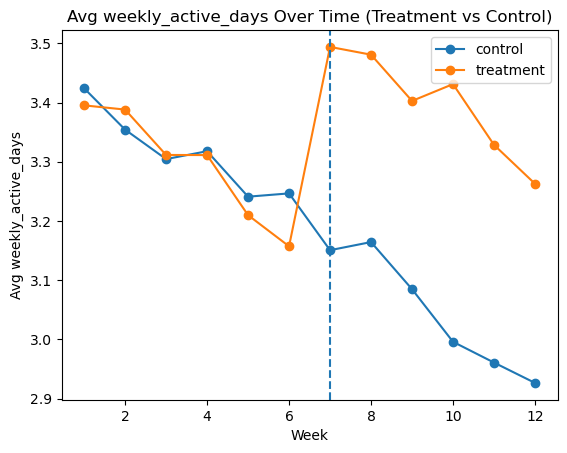

In [4]:
trend = (
    df.groupby(["week", "treatment_b"], as_index=False)[PRIMARY_OUTCOME]
      .mean()
      .sort_values(["week", "treatment_b"])
)

for key, g in trend.groupby("treatment_b"):
    label = "treatment" if key else "control"
    plt.plot(g["week"], g[PRIMARY_OUTCOME], marker="o", label=label)

plt.axvline(x=7, linestyle="--")
plt.title(f"Avg {PRIMARY_OUTCOME} Over Time (Treatment vs Control)")
plt.xlabel("Week")
plt.ylabel(f"Avg {PRIMARY_OUTCOME}")
plt.legend()
plt.show()

In [5]:
model = smf.ols(
    f"{PRIMARY_OUTCOME} ~ treatment * post_period + grade_level + ses_band",
    data=df
).fit(cov_type="HC3")

print(model.summary().tables[1])


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 3.8689      0.033    116.871      0.000       3.804       3.934
ses_band[T.low]          -0.9075      0.017    -52.677      0.000      -0.941      -0.874
ses_band[T.mid]          -0.4805      0.016    -30.013      0.000      -0.512      -0.449
treatment                -0.0179      0.018     -0.996      0.319      -0.053       0.017
post_period              -0.2672      0.018    -14.950      0.000      -0.302      -0.232
treatment:post_period     0.3724      0.025     14.730      0.000       0.323       0.422
grade_level              -0.0076      0.003     -2.384      0.017      -0.014      -0.001


In [6]:
TERM = "treatment:post_period"  # stable because treatment/post_period are 0/1 ints

coef = model.params[TERM]
ci_low, ci_high = model.conf_int().loc[TERM]

# Baseline = control group in pre-period (using boolean columns for safe filtering)
baseline = df.loc[(~df["post_b"]) & (~df["treatment_b"]), PRIMARY_OUTCOME].mean()
pct_lift = coef / baseline * 100

print(f"Effect ({TERM}): {coef:.3f} {PRIMARY_OUTCOME} units per week")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Baseline (control, pre): {baseline:.3f}")
print(f"Percent lift vs baseline: {pct_lift:.1f}%")


Effect (treatment:post_period): 0.372 weekly_active_days units per week
95% CI: [0.323, 0.422]
Baseline (control, pre): 3.315
Percent lift vs baseline: 11.2%


In [7]:
rows = []
for outcome in SECONDARY_OUTCOMES:
    m = smf.ols(
        f"{outcome} ~ treatment * post_period + grade_level + ses_band",
        data=df
    ).fit(cov_type="HC3")
    
    coef = m.params[TERM]
    ci_low, ci_high = m.conf_int().loc[TERM]
    
    baseline = df.loc[(~df["post_b"]) & (~df["treatment_b"]), outcome].mean()
    pct = coef / baseline * 100 if baseline != 0 else np.nan
    
    rows.append({
        "outcome": outcome,
        "effect": coef,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "baseline_control_pre": baseline,
        "pct_lift_vs_baseline": pct
    })

results_secondary = pd.DataFrame(rows)
results_secondary.round(3)

,outcome,effect,ci_low,ci_high,baseline_control_pre,pct_lift_vs_baseline
0,assignments_completed,0.237,0.196,0.278,2.382,9.947
1,engagement_index,0.305,0.262,0.347,2.848,10.697
2,assessment_score,1.379,1.124,1.634,70.664,1.952


In [8]:
df["low_baseline_eng"] = (df["baseline_engagement"] < 3.0).astype(int)

het_model = smf.ols(
    f"{PRIMARY_OUTCOME} ~ treatment * post_period * low_baseline_eng + grade_level + ses_band",
    data=df
).fit(cov_type="HC3")

print(het_model.summary().tables[1])

# Extract implied effects for low vs not-low groups
# When low_baseline_eng = 0: effect = treatment:post_period
# When low_baseline_eng = 1: effect = treatment:post_period + treatment:post_period:low_baseline_eng
base_effect = het_model.params.get("treatment:post_period", np.nan)
extra_low = het_model.params.get("treatment:post_period:low_baseline_eng", 0.0)

print("\nImplied treatment effects:")
print(f"Not-low baseline engagement (>=3.0): {base_effect:.3f}")
print(f"Low baseline engagement (<3.0): {(base_effect + extra_low):.3f}")

                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                  4.1474      0.032    129.832      0.000       4.085       4.210
ses_band[T.low]                           -0.5869      0.016    -35.857      0.000      -0.619      -0.555
ses_band[T.mid]                           -0.3273      0.015    -21.630      0.000      -0.357      -0.298
treatment                                 -0.0246      0.021     -1.168      0.243      -0.066       0.017
post_period                               -0.2647      0.021    -12.680      0.000      -0.306      -0.224
treatment:post_period                      0.2967      0.030      9.979      0.000       0.238       0.355
low_baseline_eng                          -1.6135      0.024    -67.900      0.000      -1.660      -1.567
treatment:low_baseline_eng           

In [9]:
# Collapse to student-level pre/post averages
agg = (df.groupby(["student_id", "treatment", "post_period"], as_index=False)[PRIMARY_OUTCOME]
         .mean()
         .pivot_table(index=["student_id", "treatment"], columns="post_period", values=PRIMARY_OUTCOME)
         .rename(columns={0: "pre_mean", 1: "post_mean"})
         .reset_index())

agg["delta"] = agg["post_mean"] - agg["pre_mean"]

# DiD on deltas: delta ~ treatment
robust = smf.ols("delta ~ treatment", data=agg).fit(cov_type="HC3")
print(robust.summary().tables[1])

print(f"\nStudent-level delta DiD estimate: {robust.params['treatment']:.3f}")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2670      0.016    -17.151      0.000      -0.298      -0.237
treatment      0.3719      0.022     16.667      0.000       0.328       0.416

Student-level delta DiD estimate: 0.372


In [11]:
# Compare panel vs student-level estimate + translate to 6-week cumulative impact

# Weekly (panel) DiD estimate from main model
weekly_effect = model.params["treatment:post_period"]
weekly_ci_low, weekly_ci_high = model.conf_int().loc["treatment:post_period"]

# Student-level pre/post (delta) estimate from robustness model
student_effect = robust.params["treatment"]
student_ci_low, student_ci_high = robust.conf_int().loc["treatment"]

# Heterogeneous effects (computed in Cell 7)
# base_effect and extra_low were printed there; recompute safely here in case of re-run order
base_effect = het_model.params.get("treatment:post_period", np.nan)
extra_low = het_model.params.get("treatment:post_period:low_baseline_eng", 0.0)
low_eng_effect = base_effect + extra_low

weeks_post = 6
cumulative_gain_avg = weekly_effect * weeks_post
cumulative_gain_low = low_eng_effect * weeks_post

print("=== Effect Size Summary ===")
print(f"Panel DiD (weekly): {weekly_effect:.3f}  (95% CI [{weekly_ci_low:.3f}, {weekly_ci_high:.3f}])")
print(f"Student-level DiD (weekly-equivalent): {student_effect:.3f}  (95% CI [{student_ci_low:.3f}, {student_ci_high:.3f}])")
print()
print(f"Cumulative gain over {weeks_post} post weeks (avg): {cumulative_gain_avg:.2f} additional active days per student")
print(f"Cumulative gain over {weeks_post} post weeks (low baseline engagement): {cumulative_gain_low:.2f} additional active days per student")

=== Effect Size Summary ===
Panel DiD (weekly): 0.372  (95% CI [0.323, 0.422])
Student-level DiD (weekly-equivalent): 0.372  (95% CI [0.328, 0.416])

Cumulative gain over 6 post weeks (avg): 2.23 additional active days per student
Cumulative gain over 6 post weeks (low baseline engagement): 3.23 additional active days per student


In [10]:
primary_row = pd.DataFrame([{
    "outcome": PRIMARY_OUTCOME,
    "effect": model.params[TERM],
    "ci_low": model.conf_int().loc[TERM][0],
    "ci_high": model.conf_int().loc[TERM][1],
    "baseline_control_pre": df.loc[(~df["post_b"]) & (~df["treatment_b"]), PRIMARY_OUTCOME].mean(),
}])

primary_row["pct_lift_vs_baseline"] = primary_row["effect"] / primary_row["baseline_control_pre"] * 100

summary = pd.concat([primary_row, results_secondary], ignore_index=True)
summary.round(3)


,outcome,effect,ci_low,ci_high,baseline_control_pre,pct_lift_vs_baseline
0,weekly_active_days,0.372,0.323,0.422,3.315,11.235
1,assignments_completed,0.237,0.196,0.278,2.382,9.947
2,engagement_index,0.305,0.262,0.347,2.848,10.697
3,assessment_score,1.379,1.124,1.634,70.664,1.952


## Difference-in-Differences Results & Interpretation

Using a difference-in-differences design, the intervention is estimated to increase weekly active days by **0.37 days per student** (95% CI: [0.32, 0.42]), relative to the control group, after accounting for overall time trends and baseline differences. This corresponds to an approximately **11% increase** relative to the control group’s pre-intervention baseline.

Heterogeneity analysis reveals substantially larger effects for students with low baseline engagement. For these students, the estimated increase is approximately **0.54 additional active days per week**, compared to **0.30 days** for students with higher baseline engagement, indicating diminishing returns among already-engaged users.

Expressed cumulatively, the estimated effect corresponds to approximately **2.2 additional active days per student** over the six-week post-intervention period, and approximately **3.2 additional days** for students with low baseline engagement.

Across specifications, results are stable and directionally consistent. A robustness check aggregating outcomes to the student level yields a similar effect, increasing confidence that findings are not driven by week-to-week noise.

**Decision implication:** The intervention produces modest but meaningful engagement gains overall, with disproportionately larger benefits for lower-engagement students. These results support **targeted deployment** of the intervention to maximize impact and efficiency rather than blanket rollout.